In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import rel_entr
from pathlib import Path

In [3]:
summary_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_contact_summary_5A.parquet")

print(summary_df.head())

                                     binder_sequence      method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF3   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...     Boltz-2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      Chai-1   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...  HelixFold3   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   

  binder_chain_id target_chain_id     score       score_name  contact_cutoff  \
0               B               A  0.903964         iptm+ptm            10.0   
1               A               B 

In [4]:
target_long_df = pd.read_parquet(
    "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_target_contacts_long_5A.parquet"
)

print(target_long_df.head())

                                     binder_sequence method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   

  binder_chain_id target_chain_id     score score_name  contact_cutoff  \
0               B               A  0.903964   iptm+ptm            10.0   
1               B               A  0.903964   iptm+ptm            10.0   
2 

In [5]:
rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/pairwise_method_comparisons_rank1_with_binder_ca_rmsd_and_target_shell_rmsd.parquet")
rmsd_df.columns.to_list()

['binder_sequence',
 'method_1',
 'method_2',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_binder',
 'n_ca_aligned',
 'binder_len_1',
 'binder_len_2',
 'status',
 'error',
 'binder_ca_rmsd_align_target_shell',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell']

In [6]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [7]:
rmsd_merged = rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [9]:
target_merged = target_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
target_merged = target_merged.drop(columns=["sequence"])

In [8]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [11]:
plot_target = target_merged[target_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [48]:
print(type(plot_rmsd))
plot_rmsd.columns.to_list()

<class 'pandas.DataFrame'>


['binder_sequence',
 'method_1',
 'method_2',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_binder',
 'n_ca_aligned',
 'binder_len_1',
 'binder_len_2',
 'status',
 'error',
 'binder_ca_rmsd_align_target_shell',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell',
 'design_class',
 'binding']

A. Global per-method distribution

This answers:

Across all binders, where on the target does each method tend to place contacts?

In [13]:
method_residue_counts = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .reset_index(name="count")
)

print(method_residue_counts.head())

  method  target_resseq  count
0    AF2              4      2
1    AF2              5      5
2    AF2              6     27
3    AF2              7     70
4    AF2              8     92


In [14]:
method_residue_matrix = (
    method_residue_counts
    .pivot(index="method", columns="target_resseq", values="count")
    .fillna(0)
    .sort_index(axis=0)
    .sort_index(axis=1)
)

print(method_residue_matrix.iloc[:5, :10])

target_resseq   1    2    3    4     5     6     7      8      9      10
method                                                                  
AF2            0.0  0.0  0.0  2.0   5.0  27.0  70.0   92.0   99.0  130.0
AF3            2.0  2.0  2.0  3.0   4.0  18.0  49.0   80.0   84.0   84.0
Boltz-2        1.0  1.0  1.0  1.0   5.0  13.0  51.0   79.0  107.0  140.0
Chai-1         1.0  1.0  3.0  3.0  20.0  30.0  69.0  103.0  115.0  131.0
HelixFold3     4.0  4.0  2.0  4.0   3.0   6.0  19.0   39.0   49.0   83.0


for a single binder-method structure, the distribution is effectively:

uniform over the contacted target residues and zero over all non-contacted residues

So for one binder:

if AF2 contacts 20 target residues, each gets roughly probability 1/20

if AF3 contacts 10 target residues, each gets roughly probability 1/10

it means KL is measuring:
how different the contacted target-residue sets are, plus how broad/narrow each interface is

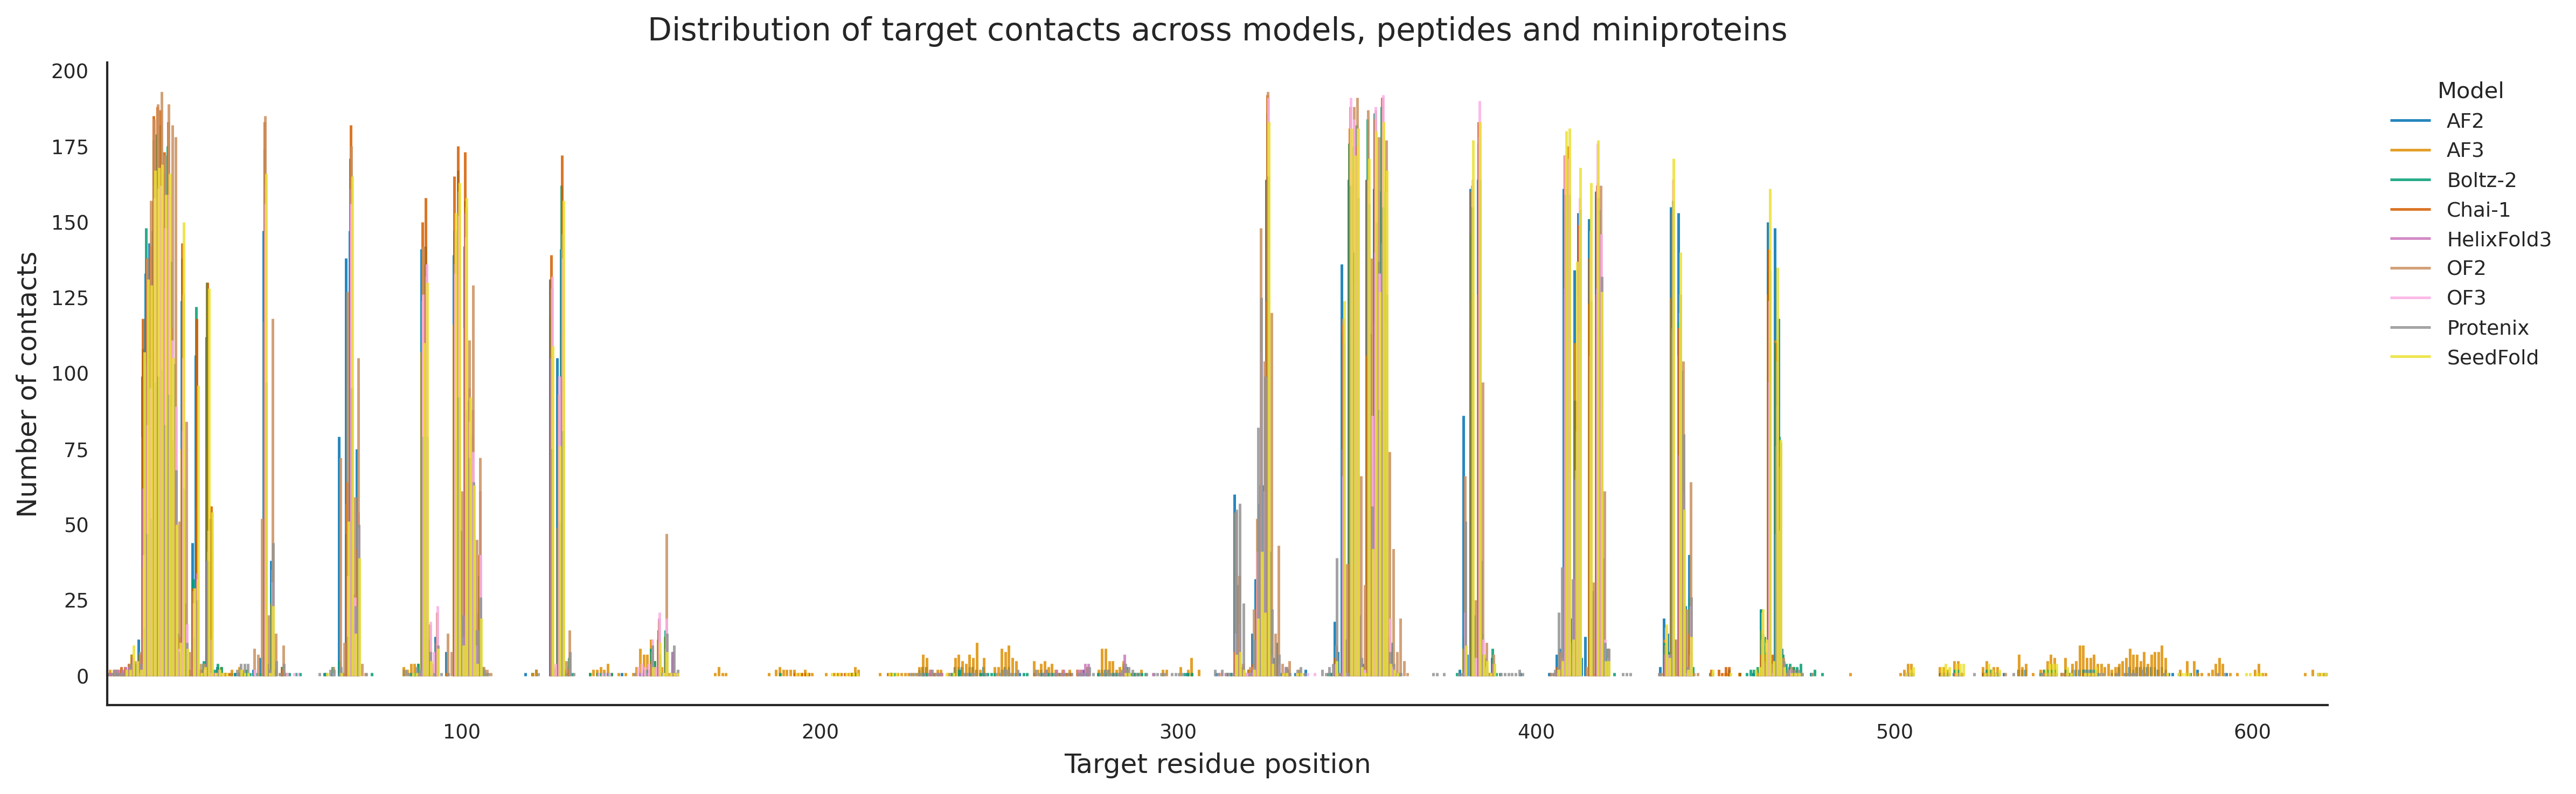

In [67]:
plot_df = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .reset_index(name="n_contacts")
)

method_order = sorted(plot_df["method"].unique())
palette = sns.color_palette("colorblind", n_colors=len(method_order))
color_map = dict(zip(method_order, palette))

offset_values = np.linspace(-0.35, 0.35, len(method_order))
offset_map = dict(zip(method_order, offset_values))

sns.set_theme(style="white", context="paper")

fig, ax = plt.subplots(figsize=(16, 5), dpi=300)

for method in method_order:
    sub = plot_df[plot_df["method"] == method]
    xvals = sub["target_resseq"] + offset_map[method]

    ax.vlines(
        x=xvals,
        ymin=0,
        ymax=sub["n_contacts"],
        color=color_map[method],
        linewidth=1.2,
        alpha=0.85,
        label=method,
    )

ax.set_xlim(1, 621)
ax.set_xlabel("Target residue position", fontsize=12)
ax.set_ylabel("Number of contacts", fontsize=12)
ax.set_title("Distribution of target contacts across models, peptides and miniproteins", fontsize=14, pad=10)

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

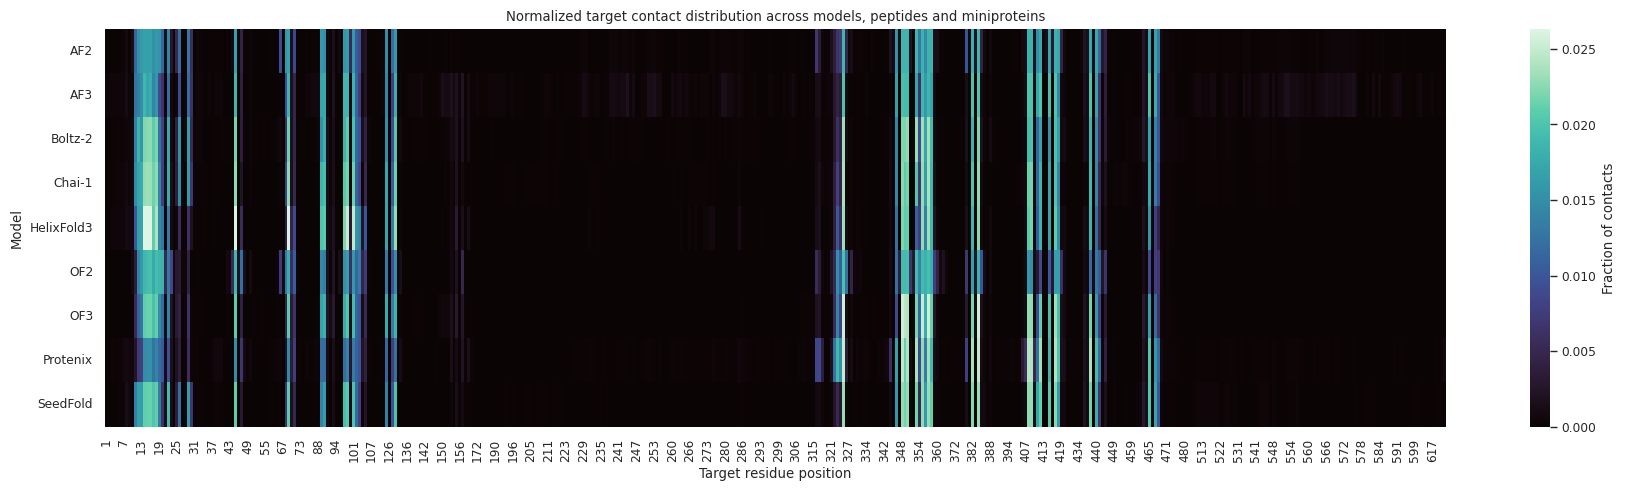

In [69]:

# Count how many times each method contacts each target residue
contact_counts = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .reset_index(name="n_contacts")
)

# Pivot to method x residue matrix
contact_matrix = (
    contact_counts
    .pivot(index="method", columns="target_resseq", values="n_contacts")
    .fillna(0)
)

contact_fraction_matrix = contact_matrix.div(contact_matrix.sum(axis=1), axis=0).fillna(0)

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(18, 5))
ax = sns.heatmap(
    contact_fraction_matrix,
    cmap="mako",
    cbar_kws={"label": "Fraction of contacts"}
)

ax.set_xlabel("Target residue position")
ax.set_ylabel("Model")
ax.set_title("Normalized target contact distribution across models, peptides and miniproteins")

plt.tight_layout()
plt.show()

In [9]:
rmsd_mean = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)["binder_ca_rmsd_align_target_shell"]
    .mean()
)

rmsd_col = "binder_ca_rmsd_align_binder"

rmsd_median = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)[rmsd_col]
    .median()
    .rename(columns={rmsd_col: "pair_median_rmsd"})
)

rmsd_median.head()

,method_1,method_2,pair_median_rmsd
0,AF2,AF3,0.932548
1,AF2,Boltz-2,1.392958
2,AF2,Chai-1,1.273865
3,AF2,HelixFold3,4.756627
4,AF2,OF2,9.300633


In [10]:
plot_rmsd_with_median = plot_rmsd.merge(rmsd_median, on=["method_1", "method_2"], how="left")

plot_rmsd_with_median.columns.to_list()

['binder_sequence',
 'method_1',
 'method_2',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_binder',
 'n_ca_aligned',
 'binder_len_1',
 'binder_len_2',
 'status',
 'error',
 'binder_ca_rmsd_align_target_shell',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell',
 'design_class',
 'binding',
 'pair_median_rmsd']

In [11]:
plot_rmsd_with_median["dist_to_pair_median"] = (
    plot_rmsd_with_median[rmsd_col] - plot_rmsd_with_median["pair_median_rmsd"]
).abs()

representative_examples = (
    plot_rmsd_with_median
    .sort_values(["method_1", "method_2", "dist_to_pair_median"])
    .groupby(["method_1", "method_2"], as_index=False)
    .head(3)
    .copy()
)

In [12]:
plot_rmsd_with_median[
    ["method_1", "method_2", "binder_ca_rmsd_align_binder", "pair_median_rmsd", "dist_to_pair_median"]
].head(20)

,method_1,method_2,binder_ca_rmsd_align_binder,pair_median_rmsd,dist_to_pair_median
0,AF2,AF3,0.405979,0.932548,0.526569
1,AF2,Boltz-2,0.717255,1.392958,0.675704
2,AF2,Chai-1,0.518000,1.273865,0.755866
3,AF2,HelixFold3,0.490231,4.756627,4.266397
4,AF2,OF2,0.253574,9.300633,9.047059
5,AF2,OF3,0.343726,8.376374,8.032648
6,AF2,Protenix,0.520128,9.044867,8.524739
7,AF2,SeedFold,0.524975,1.114157,0.589182
8,AF3,Boltz-2,0.541810,1.444703,0.902894
9,AF3,Chai-1,0.630850,1.187577,0.556727


In [13]:
cols = [
    "binder_sequence",   # or binder_id if you have one
    "method_1",
    "method_2",
    "structure_path_1",
    "structure_path_2",
    "binder_ca_rmsd_align_binder",   # or your rmsd_col
    "pair_median_rmsd",
    "dist_to_pair_median",
]

rep_view = representative_examples[cols].copy()
print(rep_view.head(30))

                                        binder_sequence method_1    method_2  \
6264    TCPEEYKGYCLHNAKCYYIEALNDVGCQCQKGFVGPRCSFKNLNEGN      AF2         AF3   
2052  LRERLIELLRQLLEEGWGTEEEREWIEERIAILEEGPEPEIVEWWL...      AF2         AF3   
1476  GTITLTIKKIEALDKYACAYEADRPITREDEDALMDKARELGYTLT...      AF2         AF3   
6265    TCPEEYKGYCLHNAKCYYIEALNDVGCQCQKGFVGPRCSFKNLNEGN      AF2     Boltz-2   
577   DEGIENFVNFMKKSQEMMKGNDEERREWHAWMRVMLEKSTNKDMTE...      AF2     Boltz-2   
4177  SDTQDVADVLLGTLKRLYEKRGLKEEYEKDKAEIEKLVEKGETDAI...      AF2     Boltz-2   
3386  PENYKSCPPSHDGYCLHGGVCMYISALQAYACNCIQGFVGERCQHS...      AF2      Chai-1   
6302    TCPEEYNGYCLNNAKCYYLKALNDVGCQCQKGFVGPRCAFKNLNENN      AF2      Chai-1   
5798  SVDEECPASHEGYCQNDGTCLLLEKLDRFACHCREGFIGDRCEERD...      AF2      Chai-1   
3459       PLSHDGLCKKCTVYLKDGKYACNCVVGYIKKGTKCYRSGLYTWE      AF2  HelixFold3   
651       DGYPPSNIMTRNPEENIDQFLEKQLYKMNLFAREDQQMQQYDRDP      AF2  HelixFold3   
3495       PLSHDGLCKKCTVYLKDGKYACNCVVGYI

In [14]:
chosen_seq = "TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF"
rmsd_col = "binder_ca_rmsd_align_binder"

binder_pairwise_df = plot_rmsd[plot_rmsd["binder_sequence"] == chosen_seq].copy()

binder_structures_df = summary_df[summary_df["binder_sequence"] == chosen_seq].copy()

In [15]:
binder_structures_view = (
    binder_structures_df[
        ["binder_sequence", "method", "path", "score", "score_name"]
    ]
    .sort_values("method")
    .reset_index(drop=True)
)

binder_structures_view.to_csv("chosen_binder_structures.csv", index=False)

print(binder_structures_view)

                    binder_sequence      method  \
0  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF         AF2   
1  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF         AF3   
2  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF     Boltz-2   
3  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF      Chai-1   
4  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF  HelixFold3   
5  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF         OF2   
6  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF         OF3   
7  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF    Protenix   
8  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF    SeedFold   

                                                path     score  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...  0.897927   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...  0.370000   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...       NaN   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...  0.719735   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for... -1.000000   
5  /home/postyr/Assessing-AI-Scoring-Accuracy-for...       NaN   
6  /home/postyr/Assessing-A

In [73]:
binder_structures_view["path"].to_csv("paths.txt", index=False, header=False)

In [16]:
ref_method = "AF3"

binder_ref_df = binder_pairwise_df[
    (binder_pairwise_df["method_1"] == ref_method) |
    (binder_pairwise_df["method_2"] == ref_method)
].copy()

binder_ref_df["other_method"] = np.where(
    binder_ref_df["method_1"] == ref_method,
    binder_ref_df["method_2"],
    binder_ref_df["method_1"]
)

binder_ref_df["af3_structure_path"] = np.where(
    binder_ref_df["method_1"] == ref_method,
    binder_ref_df["structure_path_1"],
    binder_ref_df["structure_path_2"]
)

binder_ref_df["other_structure_path"] = np.where(
    binder_ref_df["method_1"] == ref_method,
    binder_ref_df["structure_path_2"],
    binder_ref_df["structure_path_1"]
)

binder_ref_view = (
    binder_ref_df[
        [
            "binder_sequence",
            "other_method",
            rmsd_col,
            "af3_structure_path",
            "other_structure_path",
        ]
    ]
    .sort_values(rmsd_col)
    .reset_index(drop=True)
)

print(binder_ref_view)

                    binder_sequence other_method  binder_ca_rmsd_align_binder  \
0  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF          AF2                     1.015309   
1  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF       Chai-1                     1.139171   
2  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF     SeedFold                     1.193605   
3  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF   HelixFold3                     1.303910   
4  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF      Boltz-2                     1.469583   
5  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF     Protenix                     3.959436   
6  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF          OF3                     4.105781   
7  TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF          OF2                     4.231085   

                                  af3_structure_path  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-

In [ ]:
pretty_df = binder_ref_view.rename(columns={
    "other_method": "Model",
    "binder_ca_rmsd_align_binder": "Binder RMSD (Å)\n(aligned on binder)",
    "af3_structure_path": "AF3 Structure",
    "other_structure_path": "Model Structure",
})
pretty_df["Reference"] = "AF3"

rmsd_col = "Binder RMSD (Å)\n(aligned on binder)"

pretty_df[rmsd_col] = pretty_df[rmsd_col].round(2) 

pretty_df = pretty_df.sort_values(rmsd_col).reset_index(drop=True)

pretty_df = pretty_df[
    [
        "Reference",
        "Model",
        rmsd_col,
        "AF3 Structure",
        "Model Structure",
    ]
]

In [25]:
pretty_display_df = pretty_df.copy()

pretty_display_df["AF3 Structure"] = pretty_display_df["AF3 Structure"].apply(lambda x: Path(x).name)
pretty_display_df["Model Structure"] = pretty_display_df["Model Structure"].apply(lambda x: Path(x).name)
print(pretty_display_df)

  Reference       Model  Binder RMSD (Å)\n(aligned on binder)  \
0       AF3         AF2                                  1.02   
1       AF3      Chai-1                                  1.14   
2       AF3    SeedFold                                  1.19   
3       AF3  HelixFold3                                  1.30   
4       AF3     Boltz-2                                  1.47   
5       AF3    Protenix                                  3.96   
6       AF3         OF3                                  4.11   
7       AF3         OF2                                  4.23   

                               AF3 Structure  \
0  antorsae.ta_4_4_seed-0_sample-0_model.cif   
1  antorsae.ta_4_4_seed-0_sample-0_model.cif   
2  antorsae.ta_4_4_seed-0_sample-0_model.cif   
3  antorsae.ta_4_4_seed-0_sample-0_model.cif   
4  antorsae.ta_4_4_seed-0_sample-0_model.cif   
5  antorsae.ta_4_4_seed-0_sample-0_model.cif   
6  antorsae.ta_4_4_seed-0_sample-0_model.cif   
7  antorsae.ta_4_4_seed-0_samp

In [28]:
pretty_display_df.to_excel("af3_reference_table.xlsx", index=False)

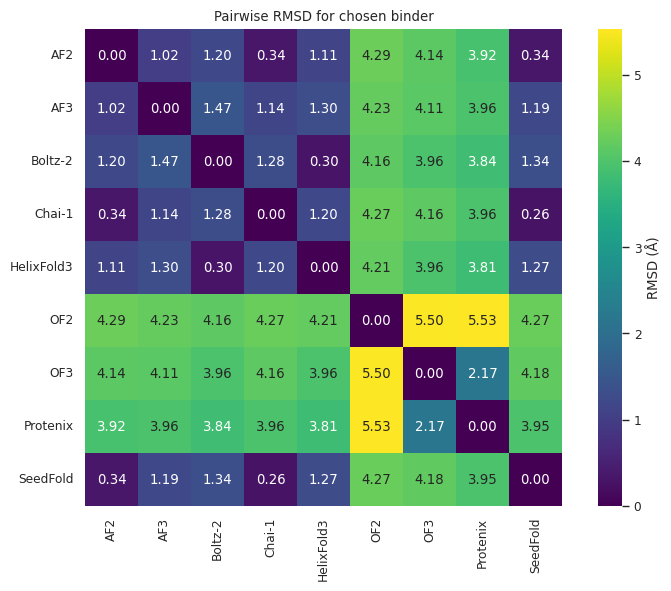

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

binder_heatmap_df = binder_pairwise_df.copy()

rmsd_matrix_2 = (
    binder_heatmap_df
    .pivot(index="method_1", columns="method_2", values=rmsd_col)
)

rmsd_matrix = rmsd_matrix_2.combine_first(rmsd_matrix_2.T)

method_order = sorted(set(binder_structures_df["method"]))
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0

plt.figure(figsize=(8, 6))
sns.heatmap(
    rmsd_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    cbar_kws={"label": "RMSD (Å)"}
)
plt.title("Pairwise RMSD for chosen binder")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [72]:
pml_path = Path("chosen_binder_all_models_align_to_AF3.pml")

with open(pml_path, "w") as f:
    for _, row in binder_structures_view.iterrows():
        f.write(f'load {row["path"]}, {row["method"]}\n')
    f.write("hide everything\n")
    f.write("show cartoon\n")
    for method in binder_structures_view["method"]:
        if method != "AF3":
            f.write(f"align {method}, AF3\n")
    f.write("zoom\n")

In [18]:
rmsd_matrix = (
    rmsd_median
    .pivot(index="method_1", columns="method_2", values="binder_ca_rmsd_align_target_shell")
)
rmsd_matrix = rmsd_matrix.combine_first(rmsd_matrix.T)

method_order = sorted(set(rmsd_matrix.index) | set(rmsd_matrix.columns))
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

In [19]:
for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0

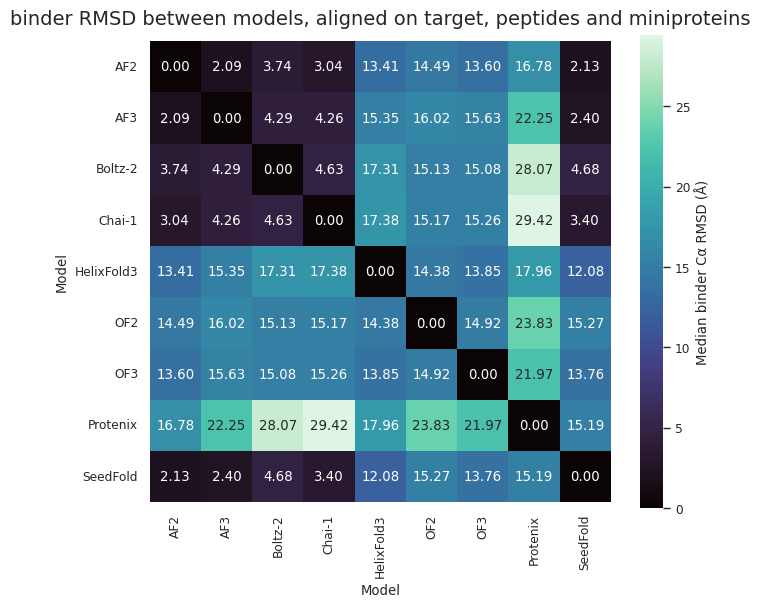

In [20]:
sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))

ax = sns.heatmap(
    rmsd_matrix,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)

ax.set_title("binder RMSD between models, aligned on target, peptides and miniproteins", fontsize=14, pad=12)
ax.set_xlabel("Model")
ax.set_ylabel("Model")

plt.tight_layout()
plt.show()

In [110]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_align_target_shell"  # adjust if needed

af3_as_1 = plot_rmsd[plot_rmsd["method_1"] == ref].copy()
af3_as_1["other_method"] = af3_as_1["method_2"]

af3_as_2 = plot_rmsd[plot_rmsd["method_2"] == ref].copy()
af3_as_2["other_method"] = af3_as_2["method_1"]

af3_all = pd.concat([af3_as_1, af3_as_2], ignore_index=True)

print(sorted(af3_all["other_method"].unique()))

['AF2', 'Boltz-2', 'Chai-1', 'HelixFold3', 'OF2', 'OF3', 'Protenix', 'SeedFold']


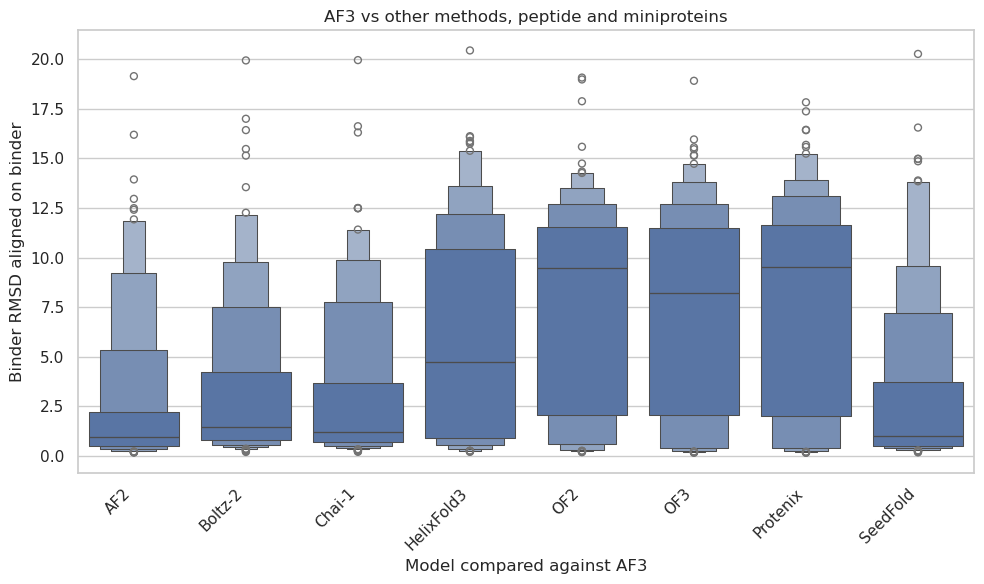

In [104]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=af3_all,
    x="other_method",
    y=rmsd_col,
    order=sorted(af3_all["other_method"].unique()),
    width_method="linear"
)

plt.xlabel("Model compared against AF3")
plt.ylabel("Binder RMSD aligned on binder")
plt.title("AF3 vs other methods, peptide and miniproteins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

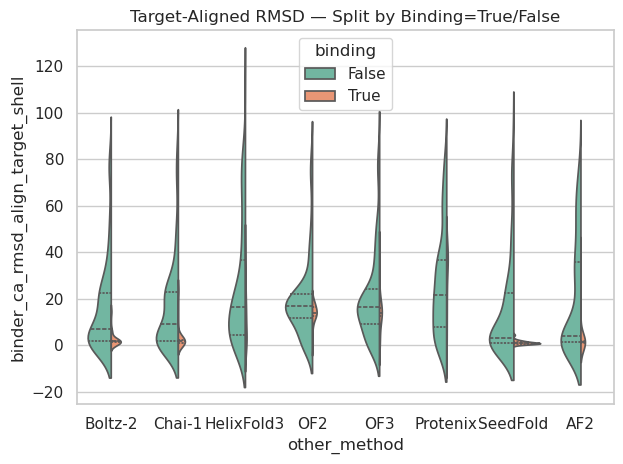

In [112]:

sns.violinplot(
    data=af3_all,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    hue="binding",             # split by True/False
    split=True,                # the magic option
    inner="quartile",          # shows quartile lines
    palette="Set2"
)

plt.title("Target-Aligned RMSD — Split by Binding=True/False")
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd

rmsd_col = "binder_ca_rmsd_align_target_shell"

# Stack both columns into one unified "method" column
part1 = plot_rmsd[["method_1", rmsd_col]].rename(columns={"method_1": "method"})
part2 = plot_rmsd[["method_2", rmsd_col]].rename(columns={"method_2": "method"})

long_df = pd.concat([part1, part2], ignore_index=True)

summary = (
    long_df
    .groupby("method")[rmsd_col]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

print(summary)

                 mean     median        std  count
method                                            
SeedFold    13.038062  10.038414  15.149856   1576
AF2         13.529594   9.355574  15.423354   1576
Boltz-2     15.687233  13.618392  15.269919   1576
Chai-1      15.718355  13.677597  15.272020   1576
OF2         16.820610  15.245467  11.797115   1576
OF3         17.182753  14.683387  13.548284   1576
HelixFold3  18.267003  14.691855  16.775369   1576
AF3         18.721070  13.897011  20.803154   1576
Protenix    23.473437  19.938049  16.900073   1576


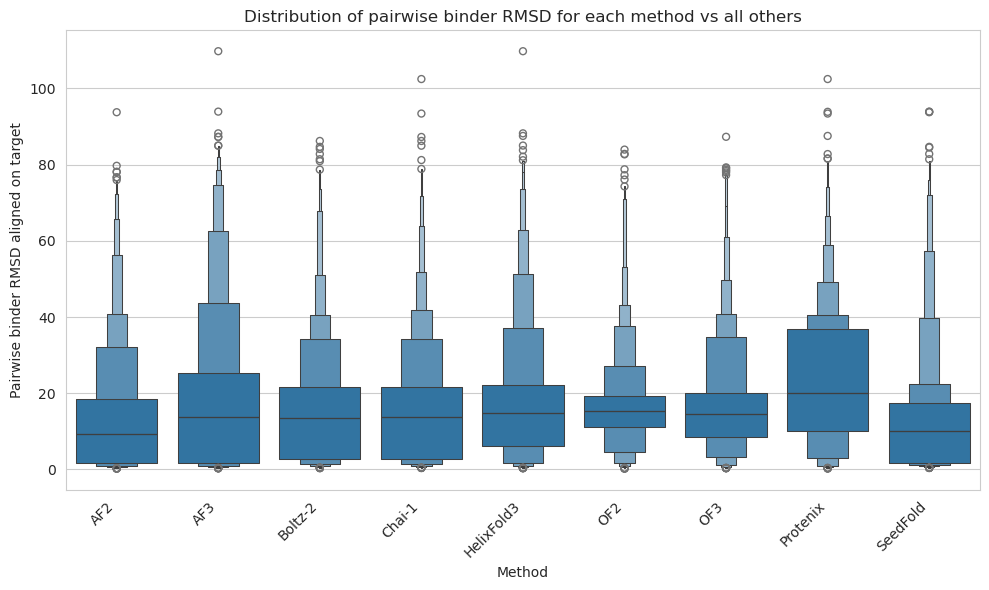

In [20]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.boxenplot(
    data=long_df,
    x="method",
    y=rmsd_col
)

plt.xlabel("Method")
plt.ylabel("Pairwise binder RMSD aligned on target")
plt.title("Distribution of pairwise binder RMSD for each method vs all others")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

which methods tend to produce poses most similar to the overall consensus across binders?

The lower the Pairwise RMSD, the more in agreement the model is in general with the other models.